## <span style="background-color:#ffdef1; color:#ff009b; padding:4px; border-radius:5px;"> 추천 시스템 </span>

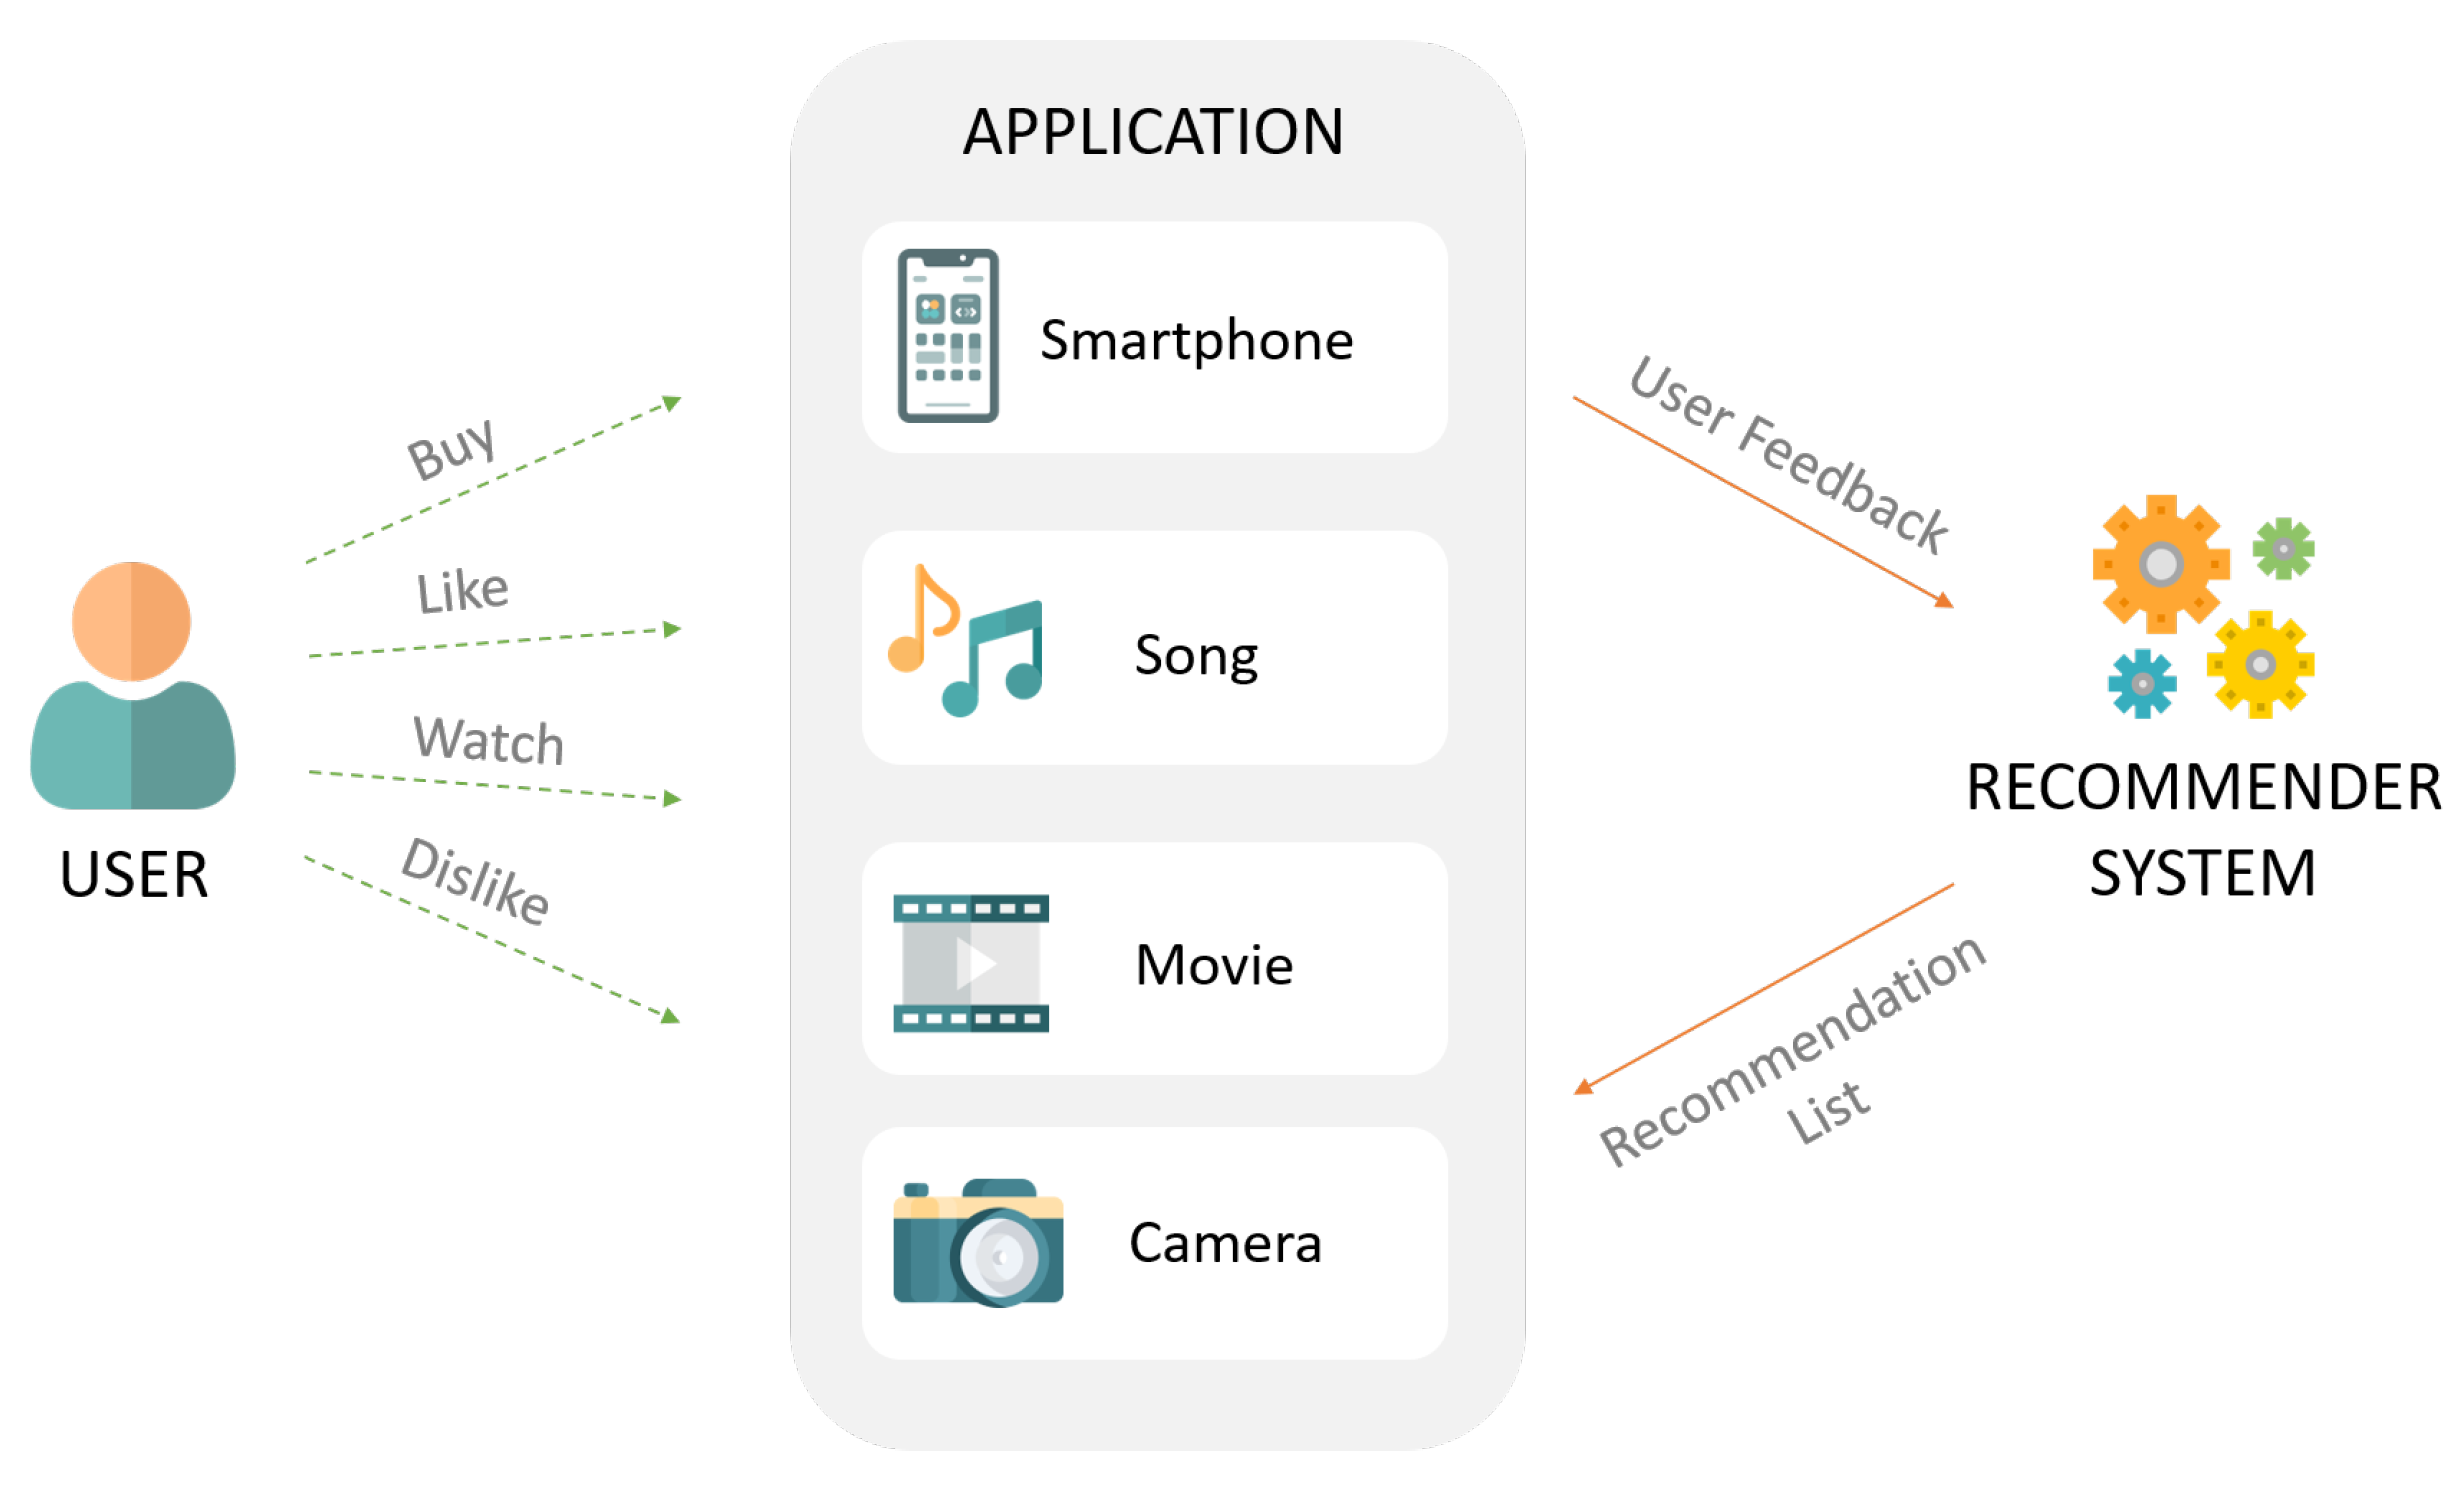

> 사용자의 정보 데이터를 분석하고, 개인 취향에 맞는 아이템 추천하는 알고리즘

명시적 데이터 (고객들에 의해 입력된 데이터: 평점, 좋아요, 투표...)와 암시적 데이터(고객 행동 기반으로 수집된 데이터: 조회수, 영상 시청 기간, 구매 기록...)를 사용한다

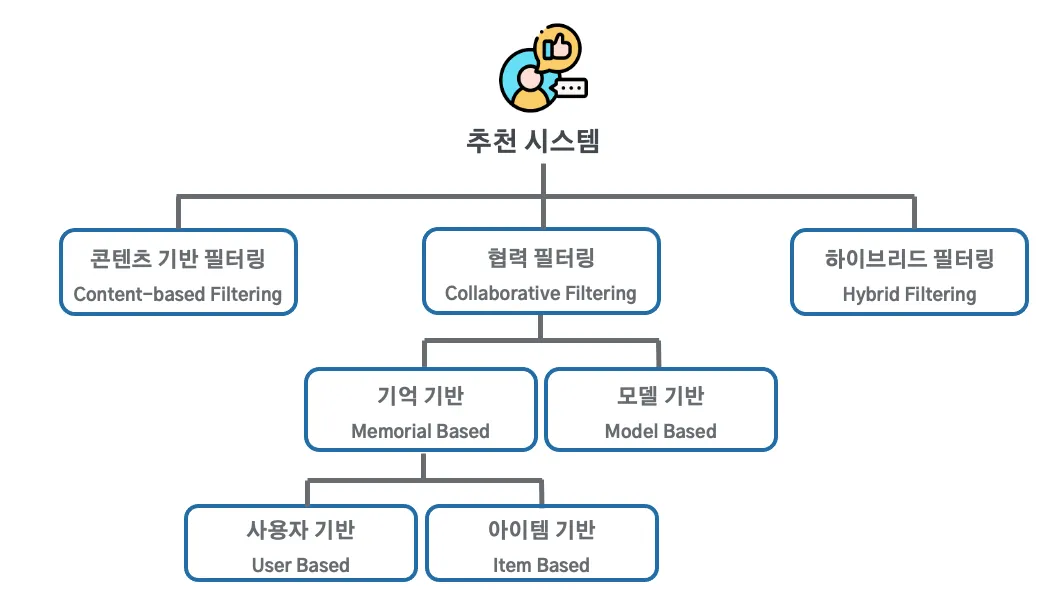

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> 내용 기반 필터링 </span>

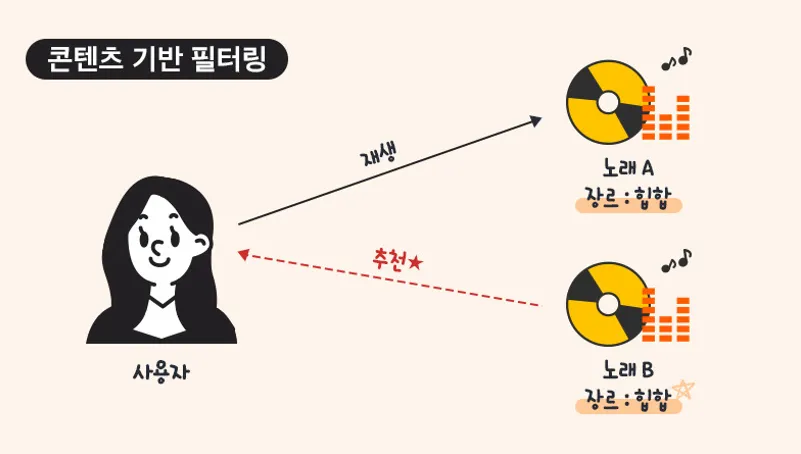

사용자의 행동 이력을 기준으로 추천!
> 콘텐츠의 **유사도** 기반으로 사용자에게 추천

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 사용자 프로필 </span>

 **사용 데이터**
1. 직접 지정형 : 사용자에게 선호 아이템 특징을 명시적으로 지정하게 함
2. 간접 지정형 : 사용자 행동 이력 기반 작성

어떻게 획득?

1. 특성 가중치는 사용자가 가지고 있는 아이템 특성 가중치 평균 값 활용
2. 사용자 기호 따로 파악 / 설문조사 or 자발적 키워드 입력으로 프로필 획득
3. 아이템에 대한 유저의 기존 평가 바탕으로 분류 문제 해결!

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 유사도 </span>

1. 아이템 정보 데이터 벡터화
2. 아이템 벡터 간의 유사도 측정
3. 유사도 높은 아이템 선별

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> TF-IDF </span>

 - TF: 특정 문서에서 특정 단어 빈도
 - IDF: 전체 문서에서 특정 단어가 얼마나 자주 등장했는지...

 > 높을수록 그 단어가 다른 문서보다 해당 문서에서 더 중요한 역할을 함!

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> 협업 필터링 </span>
> 과거에 비슷한 선호도를 가진 사용자들은 앞으로도 비슷한 선호도를 가질 것이다~

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 메모리 기반 협업 필터링 </span>
> 사용자 or 아이템 간 유사도를 기반으로 함!
> 사용자 A와 비슷한 취향을 가진 사용자가 선호하는 아이템 추천

 1. 사용자 기반 접근
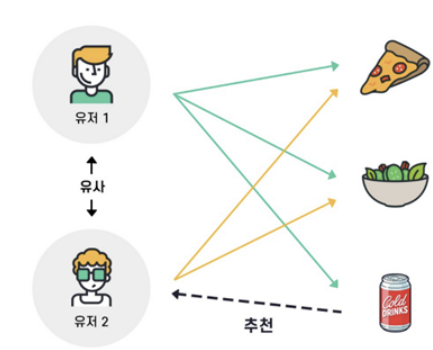

 > 타겟 유저와 유사한 **사용자**들의 평점 활용

 2. 아이템 기반 접근
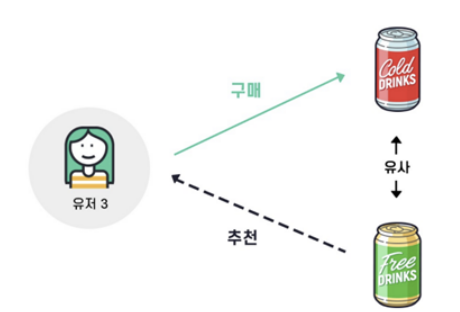
 > 타겟 아이템과 유사한 **아이템**의 평점 활용


 **메모리 기반 협업 필터링의 한계**
 - 희소 행렬 문제: 데이터 적을수록 성능 저하...
 - 아이템/유저 늘어날수록 확장성 down
 - 데이터가 아예 없는 경우 추천 불가능...

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 모델 기반 협업 필터링 </span>
  > 관측된 평점 데이터 학습 -> 관측되지 않은 평점을 예측!

  1. 잠재 요인 <br>
  : 사용자와 아이템 사이의 관계를 설명해 주는 암묵적 특성
  
  2. Latent Factor 모델
  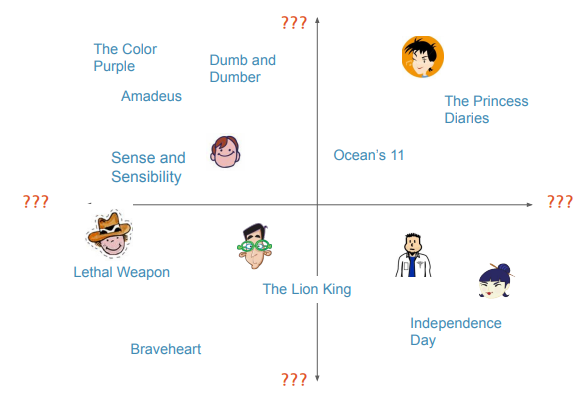

  잠재요인을 찾기 위해 사용자 잠재요인 / 아이템 잠재요인으로 각각 분해하여 학습하는 모델!

  - 차원의 수는 모델이 알아서 결정하기 때문에 사람이 해석 불가...

  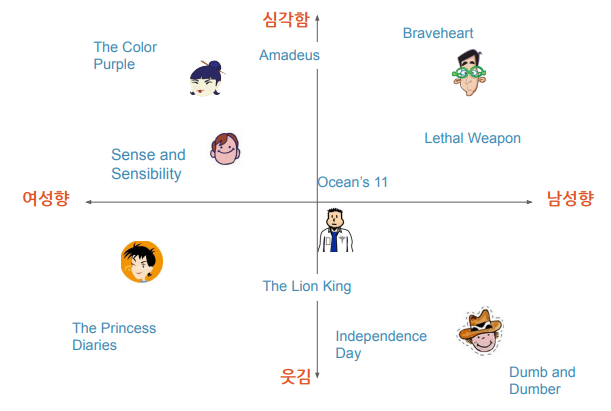
  Factor model: 유저와 아이템을 구분 없이 동일한 차원
  -> 유저와 아이템이 같은 공간에 놓이니 서로의 거리나 각도로 유사도 파악 가능

  2. 행렬 분해
  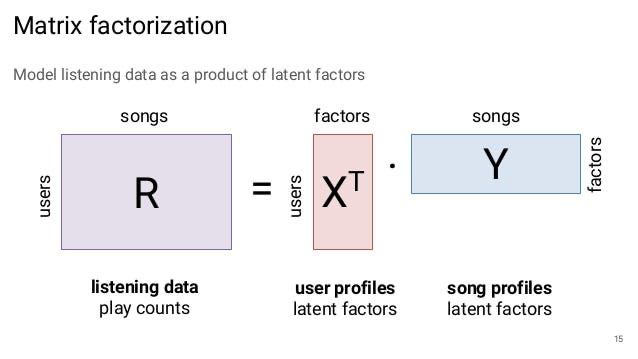
  > 행렬을 분해하여 평점을 유저의 잠재 요인과 아이템 잠재 요인의 내적으로 설명 -> 평점 예측

  ##### <span style="background-color:#DCDCDC; color:#000000; padding:4px; border-radius:5px;"> SVC: 특이값 분해 </span>
> 어떤 직사각형 행렬이든 다음의 세 행렬로 분해할 수 있는 방법

$A=UΣV^T$

- $A$ : 원래의 $m×n$ 행렬 (사용자-아이템 평점 행렬)
- $U$ :  $m×m$ 직교 행렬 (사용자 관련 정보)
- $Σ$ : $m×n$ 대각 행렬 (가장 중요한 정보: **특이값**)
- $V^T$ : $n×n$ 직교 행렬 (아이템 관련 정보)

| 구분 | Full SVD (완전 특이값 분해) | Truncated SVD (절단 특이값 분해) |
| --- | --- | --- |
| **사용** | 모든 특잇값과 벡터 사용 | 상위 $k$개의 큰 특잇값과 해당 벡터만 사용 |
| **적용** | 밀집 행렬(Dense Matrix)에 적합 | **희소 행렬(Sparse Matrix) 압축 및 노이즈 제거** |

##### <span style="background-color:#DCDCDC; color:#000000; padding:4px; border-radius:5px;"> SGD </span>
> 관측된 평점($r_{u, i}$)과 예측 평점($\hat{r}_{u, i}$) 사이의 오차를 최소화

$\min(P, Q) \sum_{(u, i) \in \mathcal{K}} (r_{u,i} - \hat{r}_{u,i})^2 + \lambda (\sum_u \|p_u\|^2 + \sum_i \|q_i\|^2)$

- $\mathcal{K}$ : 평점이 관측된 $(u, i)$ 쌍의 집합.
- $\lambda$ : 정규화 계수

목적 함수: `오차의 제곱합을 최소화`하고, `과적합을 방지하기 위한 정규화`(Regularization) 항을 추가

-> SVD의 `데이터 희소성 처리 불가`와 `계산 복잡성`이라는 한계를 보완하기 위한 방법

##### <span style="background-color:#DCDCDC; color:#000000; padding:4px; border-radius:5px;"> NMF </span>
> 분해된 두 개의 행렬 $P$와 $Q^T$의 모든 원소가 0 이상이어야 한다는 제약 조건을 추가한 행렬 분해 기법

`직관적 의미 부여 가능`

잠재 요인 값은 음수가 될 수 x (현실 데이터는 음수가 될 수 없으니...)

-> 각 잠재 요인 값이 유저 선호도나 아이템 특성 강도 나타냄을 직관적으로 해석

##### <span style="background-color:#DCDCDC; color:#000000; padding:4px; border-radius:5px;"> PMF </span>
> 평점 예측에 확률 분포를 사용하여 불확실성까지 모델링하는 통계적 접근법

`누가 무엇을 좋아할지` 예측하는 데에 목표

## <span style="background-color:#ffdef1; color:#ff009b; padding:4px; border-radius:5px;"> 딥러닝 기반 추시! </span>

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> VAE </span>

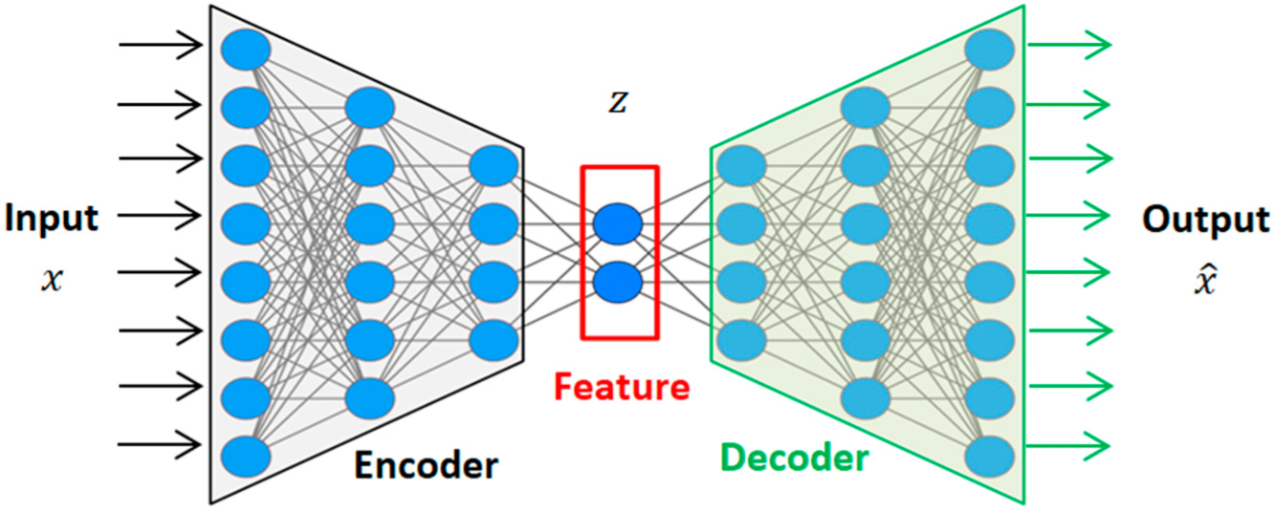

> 사용자의 아이템 상호작용 벡터(예: 구매/시청 이력)를 입력으로 받아, 잠재 공간에서 재구성하도록 VAE를 학습하는 방식

- 확률적 잠재 분포로 사용자 선호를 모델링하여 불확실성 반영
- 희소한 상호 작용 데이터에서도 강건

ex) Mult-VAE


### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> GNN </span>
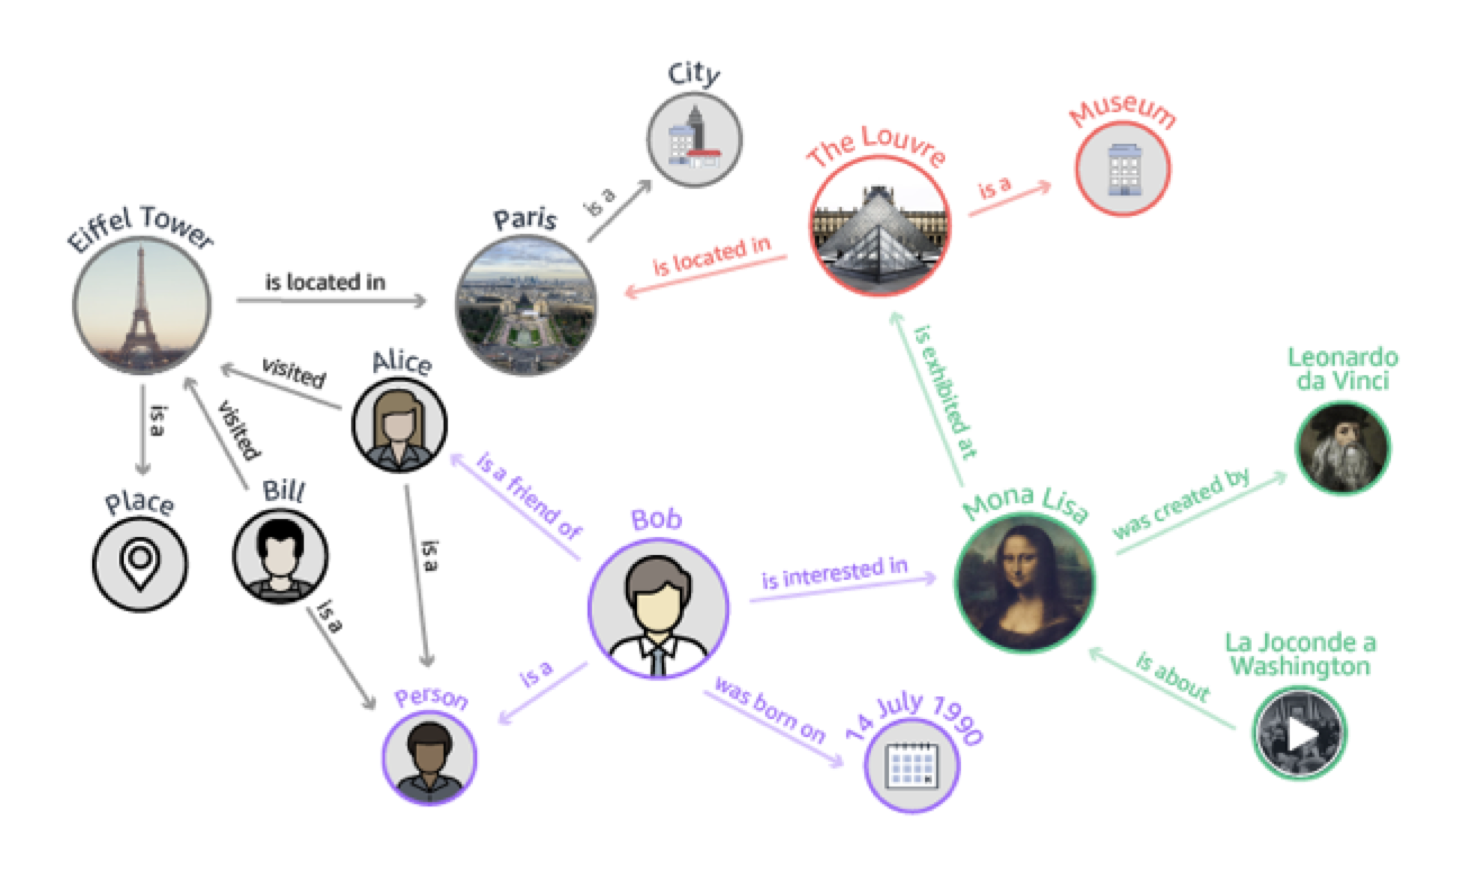

> 내 이웃 노드(나와 비슷한 사용자, 내가 본 아이템)의 정보를 나에게 전달/요약(Message Passing)

1. 그래프 구조 생성
2. 메시지 패싱: ‘메시지 생성 - 집계 - 갱신’


1. 고차원 협업 시그널 포착 가능
2. 정형화되지 않은 데이터 학습 가능
3. Cold Start 문제 완화

but...
1. 과평탄화 문제
2. 과압축 문제
3. 계산 복잡도
4. 해석의 어려움: 순서 반영 x


### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> 트포 </span>
> 행동 순서와 문맥으로 사용자 의도 파악

Attention 써서 시간 순서나 거리에 얽매이지 않고, 전체 시퀀스 내에서 현재 의도와 가장 관련성이 높은 핵심 문맥을 정확히 주목하여 예측

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> SASRec</span>
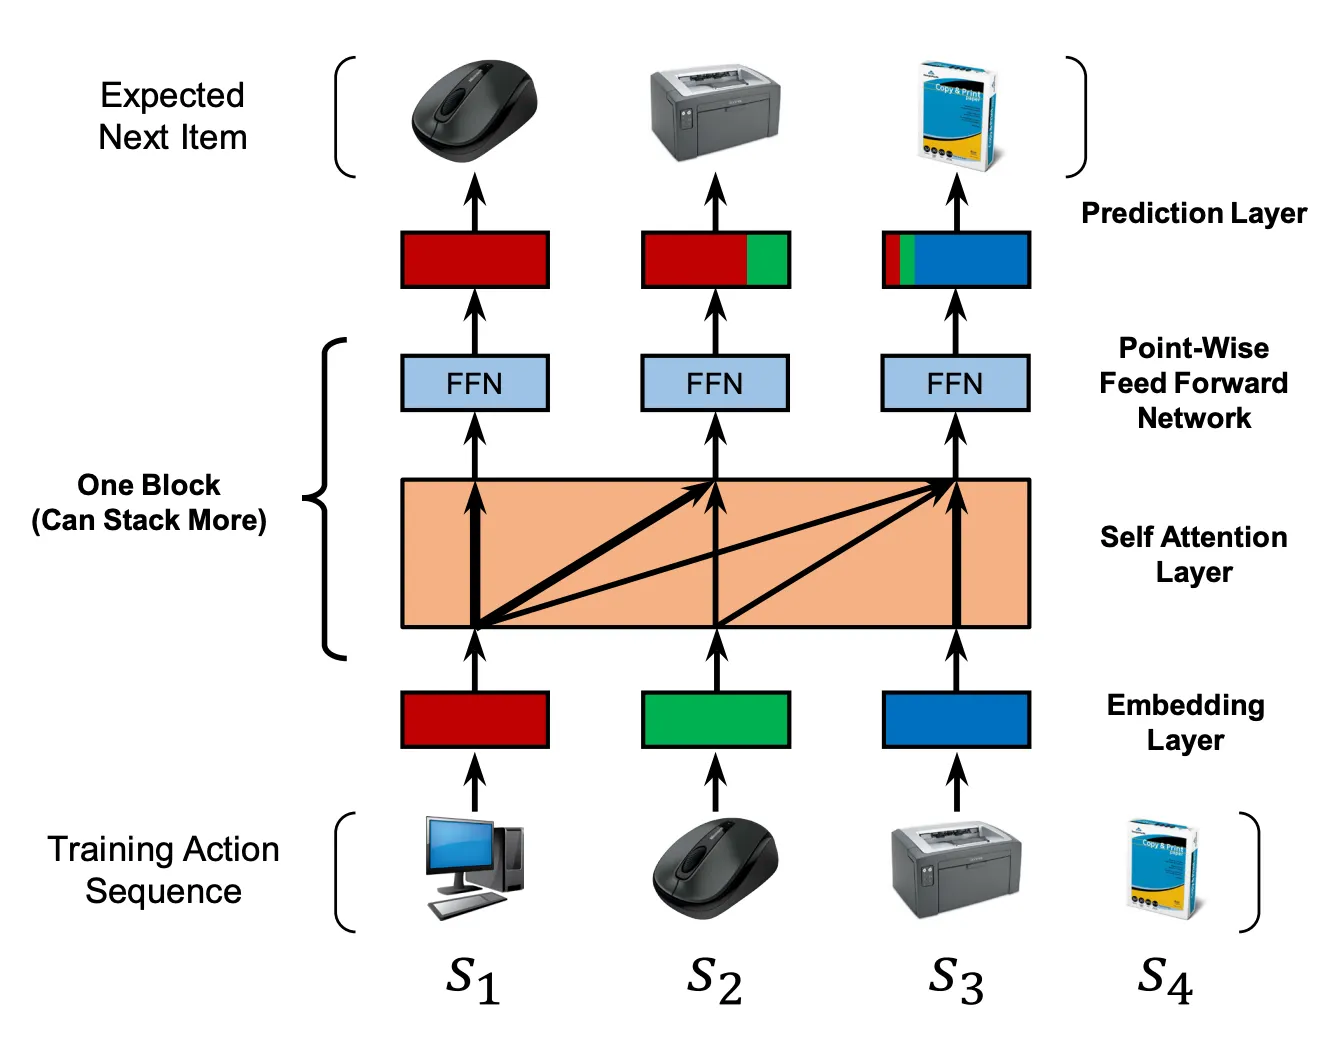

> 단방향으로 과거의 아이템만 참조하여 미래 행동 추측!

*but...* 계산량 많고 단방향성

보완한 게
##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> BERT4Rec</span>
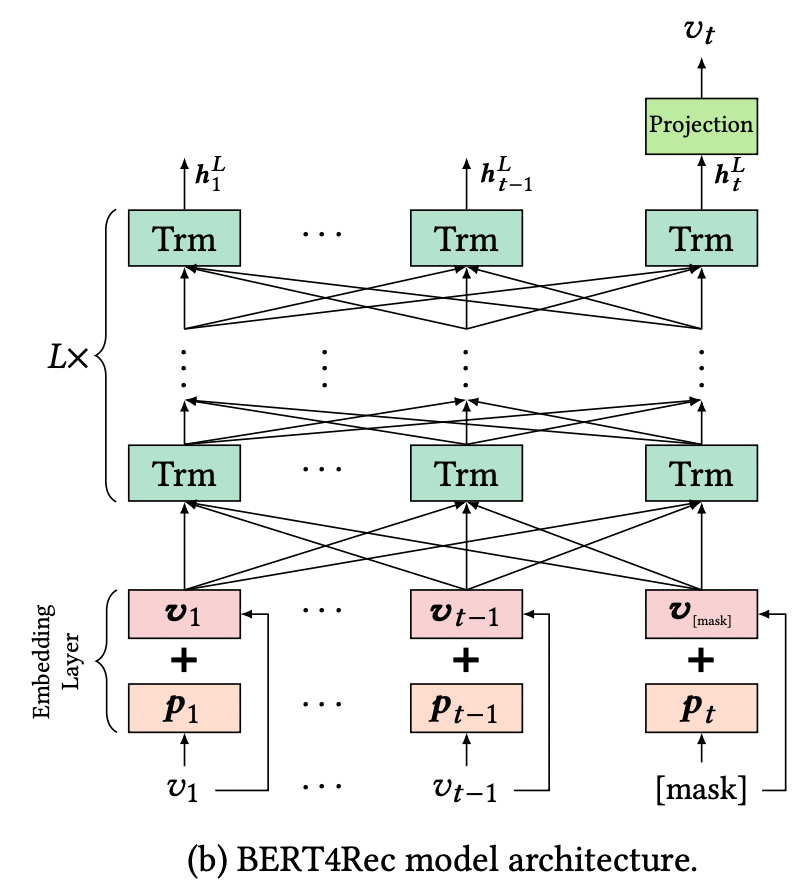

> 앙방향 어텐션으로 시퀀스 전체의 선호도 파악